In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import sklearn as skl
from sklearn.model_selection import train_test_split
from sklearn.linear_model import  LogisticRegression


In [2]:
column_names=['pregnant','glucose','bp','skin','insulin','bmi','predigree','age','label']
data_set=pd.read_csv("C:\ProgramData\Microsoft\Windows\Start Menu\Programs\Anaconda3 (64-bit)\pima-indians-diabetes.csv ",header=None,names=column_names,skiprows=(0,0))

In [3]:
data_set.head()

,pregnant,glucose,bp,skin,insulin,bmi,predigree,age,label
0,1,85,66,29,0,26.6,0.351,31,0
1,8,183,64,0,0,23.3,0.672,32,1
2,1,89,66,23,94,28.1,0.167,21,0
3,0,137,40,35,168,43.1,2.288,33,1
4,5,116,74,0,0,25.6,0.201,30,0


In [4]:
data_set.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 767 entries, 0 to 766
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   pregnant   767 non-null    int64  
 1   glucose    767 non-null    int64  
 2   bp         767 non-null    int64  
 3   skin       767 non-null    int64  
 4   insulin    767 non-null    int64  
 5   bmi        767 non-null    float64
 6   predigree  767 non-null    float64
 7   age        767 non-null    int64  
 8   label      767 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
data_set.describe()

,pregnant,glucose,bp,skin,insulin,bmi,predigree,age,label
count,767.000000,767.000000,767.000000,767.000000,767.000000,767.000000,767.000000,767.000000,767.000000
mean,3.842243,120.859192,69.101695,20.517601,79.903520,31.990482,0.471674,33.219035,0.348110
std,3.370877,31.978468,19.368155,15.954059,115.283105,7.889091,0.331497,11.752296,0.476682
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243500,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,32.000000,32.000000,0.371000,29.000000,0.000000
75%,6.000000,140.000000,80.000000,32.000000,127.500000,36.600000,0.625000,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [6]:
#conversion of string into numeric
convert_col=['pregnant','insulin','bmi','age','glucose','bp','predigree' ]
for col in convert_col:
    data_set[col]=pd.to_numeric(data_set[col])

In [7]:
#feature selection
features_Colums=['pregnant','insulin','bmi','age','glucose','bp','predigree' ]
x=data_set[features_Colums]
y=data_set.label

C:\py\Lib\site-packages\seaborn\matrix.py:260: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)


Text(0.5, 300.7222222222222, 'Feature Value on X axis')

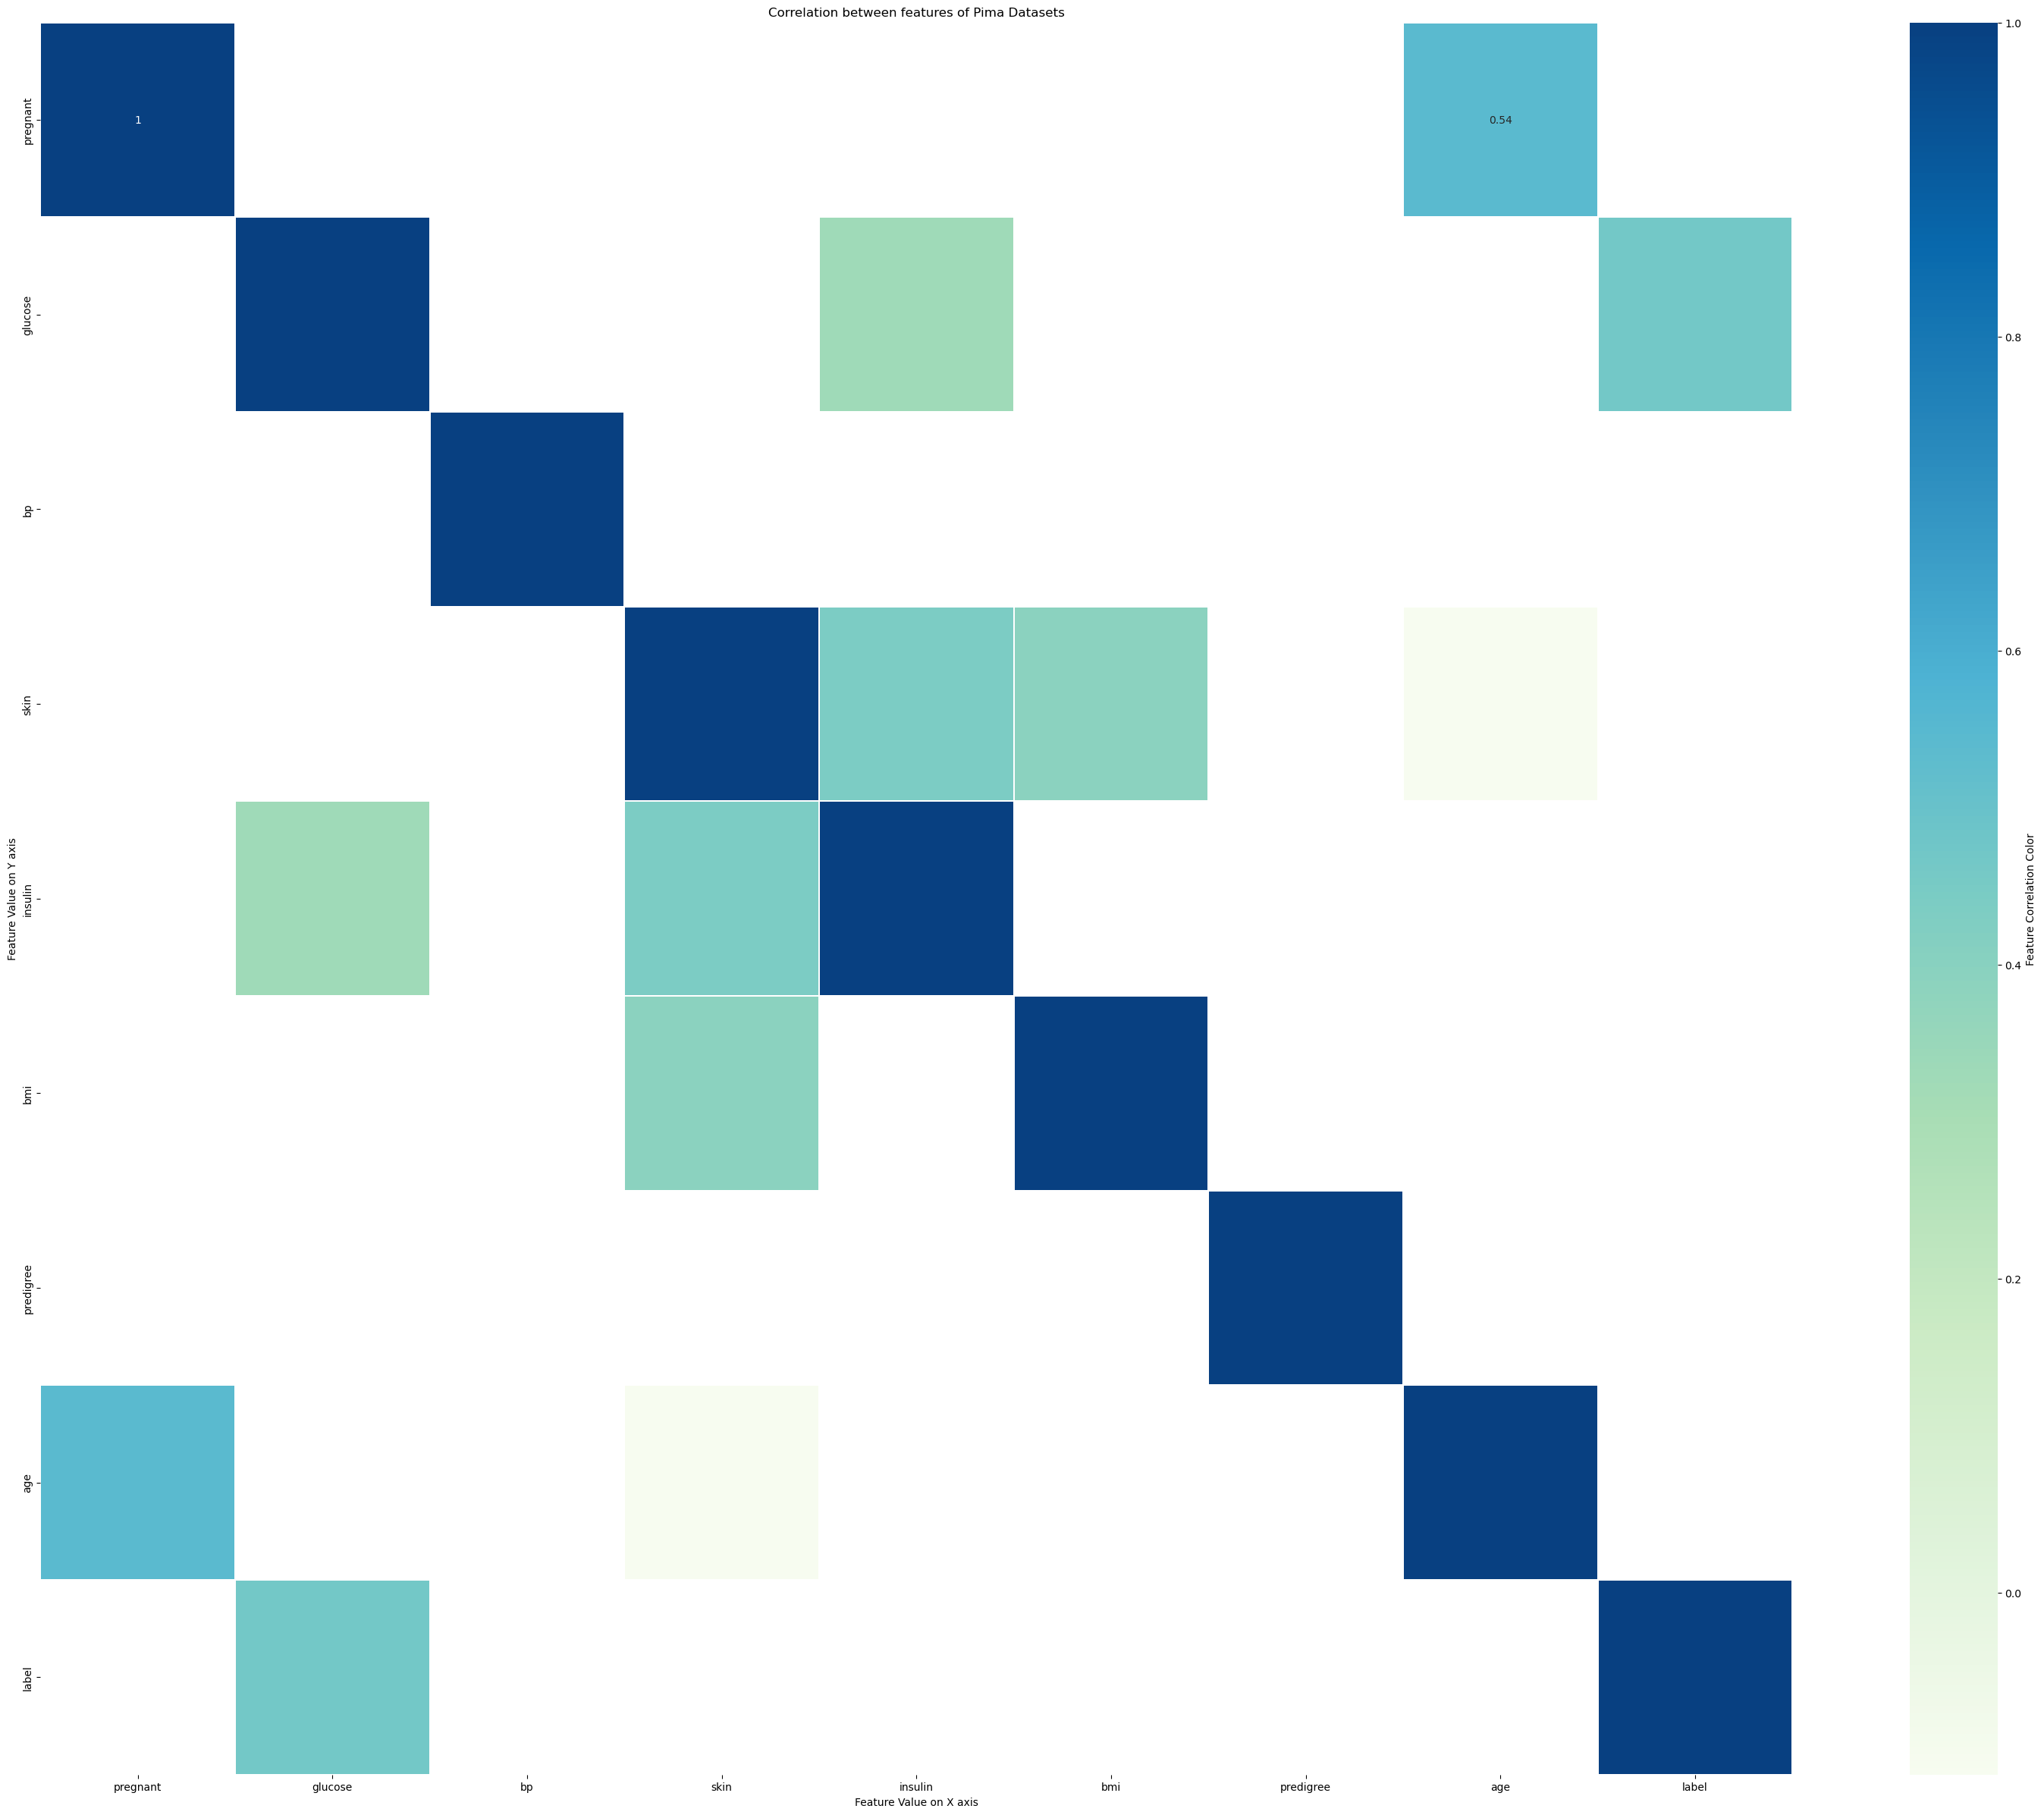

In [8]:
corr = data_set.corr()
plt.figure(figsize=(40,30))
coor_range = corr[(corr >= 0.3) | (corr <= -0.1)]  # Adjusting the correlation threshold
sns.heatmap(coor_range, annot=True,linewidths=0.01, square=True, cmap='GnBu', linecolor="white", cbar_kws={'label': 'Feature Correlation Color'})
plt.title("Correlation between features of Pima Datasets")
plt.ylabel("Feature Value on Y axis")
plt.xlabel("Feature Value on X axis")

In [9]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=42)


In [10]:
logistic_function = LogisticRegression()

In [11]:
#Fit the model with the training dat
logistic_function.fit(x_train,y_train)
y_prediction=logistic_function.predict(x_test)
#to se the y prediction data
#displiy(y_prediction)

In [12]:
#Model Evaluction using Confusion matrix for the performance of classification model
from sklearn import metrics
cnf_matrix_evaluation = metrics.confusion_matrix(y_test, y_prediction)
cnf_matrix_evaluation

array([[87, 10],
       [19, 38]], dtype=int64)

In [13]:
# Visualization of confusion matrix using heatmap
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

Text(0.5, 427.9555555555555, 'Predicted label')

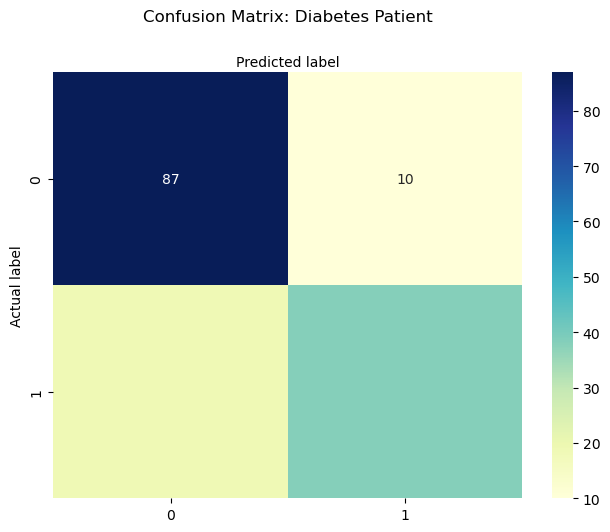

In [14]:
class_names = [0, 1]
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)

# Creating the heatmap for the confusion matrix
sns.heatmap(pd.DataFrame(cnf_matrix_evaluation), annot=True, cmap="YlGnBu", fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion Matrix: Diabetes Patient', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
 

In [15]:
#confusion Matrix conclusion for the evalution metrics
print("Accuracy:",metrics.accuracy_score(y_test,y_prediction))
print("Precision:",metrics.precision_score(y_test,y_prediction))
print("Recall:",metrics.recall_score(y_test,y_prediction))
print(metrics.accuracy_score(y_test,y_prediction)*100," % :","chances that persion having dibetes in the present dataset")
print(y_prediction)

Accuracy: 0.8116883116883117
Precision: 0.7916666666666666
Recall: 0.6666666666666666
81.16883116883116  % : chances that persion having dibetes in the present dataset
[0 0 0 0 0 0 0 0 1 0 1 1 0 1 1 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 1 0 0 1 1
 0 0 0 0 1 1 0 0 0 1 1 1 1 0 0 0 0 0 1 0 0 0 0 1 0 0 0 1 1 1 0 0 0 0 0 0 1
 0 1 0 0 0 1 1 1 1 0 0 1 0 0 0 1 0 0 0 0 0 0 0 1 1 0 1 0 0 1 1 0 0 0 0 0 0
 0 0 1 1 0 1 0 0 1 0 0 1 0 0 0 1 1 0 0 0 0 0 1 1 0 0 1 0 0 0 1 0 0 0 0 0 1
 0 0 0 1 0 0]


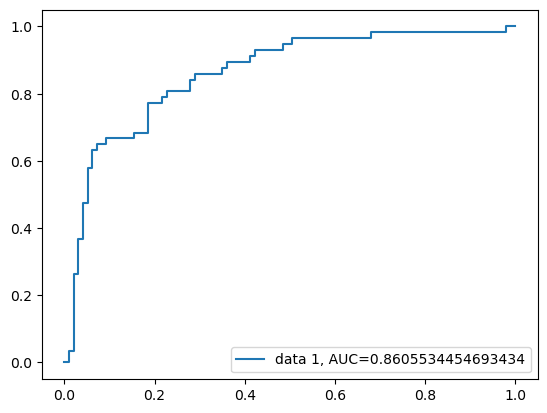

In [16]:
#Performance evaluation using the Roc curve,Receiver Operating Characterstic(roc) curve is a plot of the true positive rate
#IT shows the tradeoff between sen sitivity and specificity
y_prediction_probability = logistic_function.predict_proba(x_test)[:, 1]
fpr, tpr, _ = metrics.roc_curve(y_test, y_prediction_probability)
auc = metrics.roc_auc_score(y_test, y_prediction_probability)
plt.plot(fpr, tpr, label="data 1, AUC=" + str(auc))
plt.legend(loc=4)
plt.show()

In [17]:
from sklearn.metrics import f1_score

In [18]:
f1_score(y_test,y_prediction,average=None)
#f1_score(y_test,y_prediction,average='macro')
#f1_score(y_test,y_prediction,average='weighted')


array([0.85714286, 0.72380952])

In [1]:
# Function to predict diabetes for a new person
def check_diabetes(pregnant, glucose, bp, skin, insulin, bmi, predigree, age):
    # Put values in same order as training set
    new_data = np.array([[pregnant, glucose, bp, skin, insulin, bmi, predigree, age]])
    
    # Predict using your trained logistic model
    result = logistic_function.predict(new_data)
    
    # Show output
    if result[0] == 1:
        print("✔ The person is DIABETIC")
    else:
        print("✔ The person is NOT diabetic")


In [ ]:
## print("Enter patient details:")
preg = float(input("Pregnancies: "))
glu = float(input("Glucose Level: "))
bp = float(input("Blood Pressure: "))
skin = float(input("Skin Thickness: "))
insulin = float(input("Insulin Level: "))
bmi = float(input("BMI: "))
ped = float(input("Diabetes Pedigree: "))
age = float(input("Age: "))

check_diabetes(preg, glu, bp, skin, insulin, bmi, ped, age)


In [2]:
Pregnancies: 2
Glucose Level: 150
Blood Pressure: 72
Skin Thickness: 20
Insulin Level: 85
BMI: 32.4
Diabetes Pedigree: 0.45
Age: 35


SyntaxError: invalid syntax (4235739835.py, line 2)

In [ ]:
Pregnancies: 2
Glucose Level: 150
Blood Pressure: 72
Skin Thickness: 20
Insulin Level: 85
BMI: 32.4
Diabetes Pedigree: 0.45
Age: 35
